# *******Rezvan *******

# Libraries

In [2]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os


# Data Path and Loading

In [3]:
DATA_DIR = Path("../data/eye_tracking")

csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

[WindowsPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), WindowsPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv'), WindowsPath('../data/eye_tracking/focus distance test 2_ET_Data_Condition0_2026-05-04.csv')]
(384510, 61)


## All unique names of objects

In [5]:
unique_objs = df["hit_obj_name"].dropna().unique()
print(sorted(unique_objs))


['Ceiling', 'ContinueButton', 'Floor', 'ImageFixationCross', 'Lamp_Front_Left', 'Lego_1x3_Green', 'Lego_1x3_Pink', 'Lego_1x3_Pink (1)', 'Lego_2x2_Blue_Dis', 'Lego_2x2_Orange', 'Lego_3x2_Orange_Dis', 'Lego_4x2_Blue', 'Lego_4x2_Green', 'Lego_4x2_Green (1)', 'Lego_4x2_Orange', 'Lego_4x2_Pink_Dis', 'Lego_Board_10x10', 'ModelFront', 'Model_plate', 'NextItemButton', 'PlaneLeft', 'PlaneRight', 'QuestionButton1', 'QuestionButton2', 'QuestionButton3', 'QuestionButton4', 'QuestionButton5', 'QuestionButton6', 'QuestionButton7', 'ResourceFront', 'RotationButton', 'ValidationButtonLeft', 'ValidationButtonRight', 'Wall_Back', 'Wall_Cut', 'Wall_Front', 'Wall_Left', 'WorkBack', 'WorkLeft', 'WorkRight', 'board_stud_top_001', 'board_stud_top_002', 'board_stud_top_003', 'board_stud_top_004', 'board_stud_top_005', 'board_stud_top_006', 'board_stud_top_007', 'board_stud_top_008', 'board_stud_top_009', 'board_stud_top_010', 'board_stud_top_011', 'board_stud_top_012', 'board_stud_top_013', 'board_stud_top_01

# Estimate Sampling Rate

In [6]:
t = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
dt_ns = t.diff().dropna()

median_dt_ns = dt_ns.median()
sampling_rate_hz = 1e9 / median_dt_ns

print(f"Estimated sampling rate: {sampling_rate_hz:.2f} Hz")
print(f"Median sample interval: {median_dt_ns:.0f} ns")
print(f"Median sample interval: {median_dt_ns / 1e6:.3f} ms")

Estimated sampling rate: 199.98 Hz
Median sample interval: 5000600 ns
Median sample interval: 5.001 ms


In [7]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

df = add_time_per_model(df, time_col="gaze_capture_time")

seg = (
    df[(df["condition_number"] == 1) &
             (df["trial_number"] == 1)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

seg["dt_ms"] = seg["time_ms"].diff()
print(seg.loc[545:555, ["time_ms", "dt_ms", "left_status", "right_status", "frame_number"]].to_string())

         time_ms       dt_ms  left_status right_status  frame_number
545  2726.339200    5.003008  Compensated  Compensated        585037
546  2731.339392    5.000192      Tracked  Compensated        585038
547  2736.339712    5.000320      Tracked  Compensated        585039
548  2741.343744    5.004032      Tracked  Compensated        585040
549  2746.345088    5.001344      Tracked  Compensated        585041
550  2751.346560    5.001472      Tracked  Compensated        585042
551  2761.345792    9.999232      Tracked      Invalid        585044
552  2966.369664  205.023872  Compensated      Invalid        585085
553  3006.374016   40.004352      Invalid      Visible        585093
554  3171.398784  165.024768      Visible      Invalid        585126
555  3176.401664    5.002880      Visible      Invalid        585127


# Preprocessing Function

In [8]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

df_clean = cleaning_function(df)
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.000000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.000192
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.997184
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.997888
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.999616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.389248
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.387520
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.386944
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.386368


# Time Function

In [9]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


# Computing angular velocity in original vectors

In [10]:
def add_angular_velocity_before(df, time_col="gaze_capture_time"):
    df = df.copy()
    df = df.sort_values(["condition_number", "trial_number", time_col])
    df["angular_velocity_before"] = np.nan

    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        g = sub[[
            "gaze_forward_x",
            "gaze_forward_y",
            "gaze_forward_z"
        ]].to_numpy(dtype=float)

        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        g_prev = g[:-1]
        g_curr = g[1:]

        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        vel = np.full(len(sub), np.nan)
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        df.loc[idx, "angular_velocity_before"] = vel

    return df


In [11]:

df_clean = add_angular_velocity_before(df_clean, time_col="gaze_capture_time")


# Define Valid Samples and Interpolation

In [12]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )



In [13]:
df_clean = interpolate_all_segments(df_clean)


# Smoothing the data: 5-median filter

In [14]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df_clean[col] = (
        df_clean.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df_clean[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df_clean[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)


# Sorting

In [15]:
df_clean = df_clean.sort_values(["condition_number", "trial_number", "gaze_capture_time"])
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
0,1000325398422099900,1773140944969,41.12195,2.000000,525251,0.293504,Valid,0.012164,-0.266522,0.963752,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
1,1000325398427100300,1773140944973,41.12195,2.000000,525252,0.315788,Valid,0.013124,-0.265512,0.964018,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
2,1000325398432112600,1773140944973,41.12195,2.000000,525253,0.354264,Valid,0.014052,-0.264599,0.964256,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
3,1000325398437113000,1773140944973,41.12195,2.000000,525254,0.441358,Valid,0.014769,-0.263616,0.964515,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
4,1000325398442101200,1773140944973,41.12195,2.000000,525255,0.473352,Valid,0.015610,-0.262661,0.964762,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384505,1000328184386556900,1773143730444,1607.74300,1.276645,1082229,1.000000,Valid,-0.036495,0.168651,0.985000,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN
384506,1000328184391558700,1773143730454,1607.75400,1.277654,1082230,0.998679,Valid,-0.036406,0.169091,0.984928,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN
384507,1000328184396558500,1773143730454,1607.75400,1.278499,1082231,0.993781,Valid,-0.036322,0.169536,0.984854,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN
384508,1000328184401558700,1773143730465,1607.76500,1.277999,1082232,0.982768,Valid,-0.036273,0.170024,0.984772,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN


In [16]:
pd.set_option("display.max_columns", None)

df_clean.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,gaze_origin_y,gaze_origin_z,left_forward_x,left_forward_y,left_forward_z,left_origin_x,left_origin_y,left_origin_z,left_status,left_pupil_diameter,left_iris_diameter,left_pupil_iris_ratio,left_eye_openness,right_forward_x,right_forward_y,right_forward_z,right_origin_x,right_origin_y,right_origin_z,right_status,right_pupil_diameter,right_iris_diameter,right_pupil_iris_ratio,right_eye_openness,inter_pupillary_distance,hmd_position_x,hmd_position_y,hmd_position_z,hmd_rotation_x,hmd_rotation_y,hmd_rotation_z,hmd_rotation_w,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality,condition_number,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_velocity_before,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,0,0,0,0.047548,0.143904,0.988449,-0.033577,0,0,Tracked,4.820606,12.65099,0.381046,1.0,-0.021272,0.144035,0.989344,0.033577,0,0,Tracked,5.292973,12.58795,0.420479,0.973268,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN,True,False,False,0.013078,0.144172,0.989466,C1_T1
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,0,0,0,0.047397,0.144022,0.988439,-0.033577,0,0,Tracked,4.815219,12.65099,0.380620,1.0,-0.021240,0.144152,0.989328,0.033577,0,0,Tracked,5.293125,12.58795,0.420491,0.973297,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.420650,True,False,False,0.013059,0.144225,0.989459,C1_T1
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,0,0,0,0.047250,0.144130,0.988430,-0.033577,0,0,Tracked,4.812161,12.65099,0.380378,1.0,-0.021218,0.144258,0.989313,0.033577,0,0,Tracked,5.294265,12.58795,0.420582,0.973327,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.307756,True,False,False,0.013039,0.144279,0.989451,C1_T1
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,0,0,0,0.047095,0.144188,0.988429,-0.033577,0,0,Tracked,4.808924,12.65099,0.380122,1.0,-0.021184,0.144316,0.989305,0.033577,0,0,Tracked,5.295160,12.58795,0.420653,0.973373,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.791661,True,False,False,0.013003,0.144336,0.989443,C1_T1
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,0,0,0,0.046948,0.144232,0.988429,-0.033577,0,0,Tracked,4.806955,12.65099,0.379967,1.0,-0.021160,0.144359,0.989299,0.033577,0,0,Tracked,5.296308,12.58795,0.420744,0.973384,67.2,0.352550,1.598016,0.020432,0.079370,0.704137,-0.074286,0.701693,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,0.664515,True,False,False,0.012964,0.144336,0.989444,C1_T1


# Interpolation Check

In [17]:
def plot_interpolation_xyz(
    df_segment: pd.DataFrame,
    center_start: int,
    center_end: int,
    pad: int = 20
):
    """
    Plot raw vs cleaned x/y/z around one interpolated run.
    """
    sub = df_segment.sort_values("time_ms").reset_index(drop=True)

    a = max(0, center_start - pad)
    b = min(len(sub) - 1, center_end + pad)
    win = sub.iloc[a:b+1].copy()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    for ax, comp in zip(axes, ["x", "y", "z"]):
        raw_col = f"gaze_forward_{comp}"
        clean_col = f"clean_gaze_forward_{comp}"

        ax.plot(win["time_ms"], win[raw_col], label=f"raw {comp}")
        ax.plot(win["time_ms"], win[clean_col], label=f"clean {comp}")

        interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
        if interp_mask.any():
            interp_times = win.loc[interp_mask, "time_ms"]
            ax.axvspan(interp_times.min(), interp_times.max(), alpha=0.2)

        ax.set_ylabel(comp)
        ax.legend()

    cond = win["condition_number"].iloc[0]
    trial = win["trial_number"].iloc[0]
    axes[0].set_title(f"Condition {cond}, Trial {trial}")
    axes[-1].set_xlabel("time_ms")

    plt.tight_layout()
    plt.show()

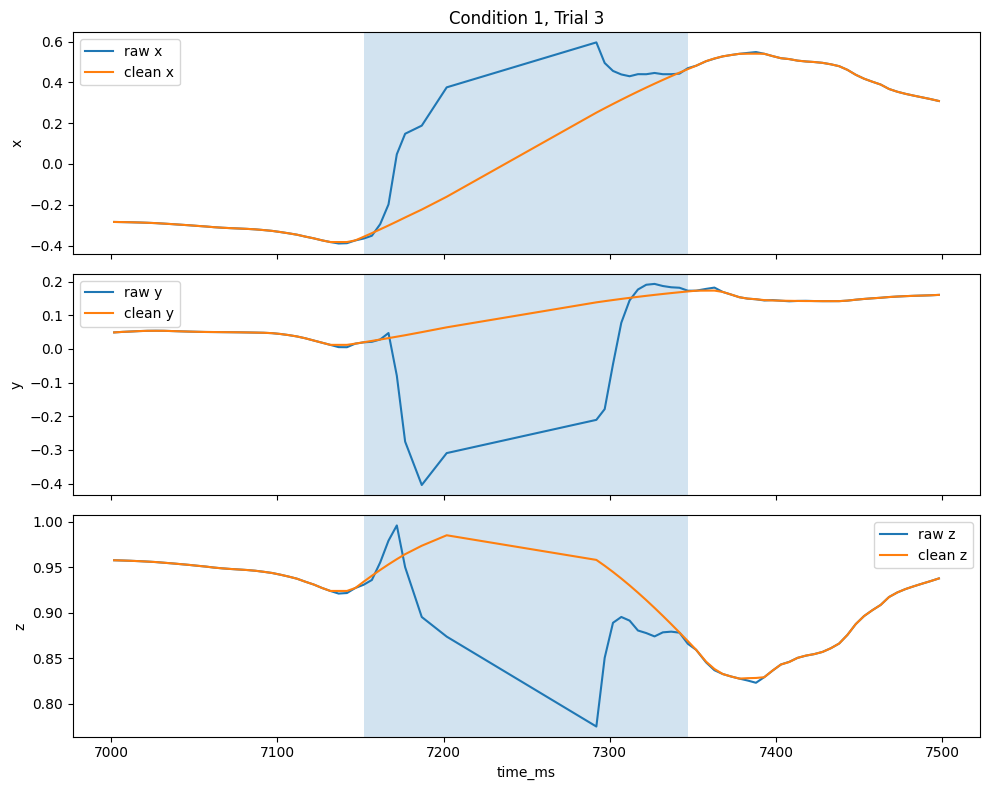

In [18]:
seg = (
    df_clean[(df_clean["condition_number"] == 1) &
             (df_clean["trial_number"] == 3)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

runs = find_runs(seg["is_interpolated"].fillna(False).to_numpy())
if runs:
    a, b = runs[0]
    plot_interpolation_xyz(seg, a, b, pad=30)



# Angular Velocity

In [19]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [20]:
df_clean = add_angular_velocity(df_clean, time_col="gaze_capture_time")

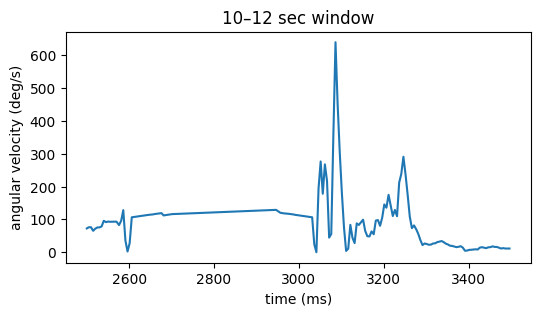

In [21]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 10 sec
    (df_clean["time_ms"] <= 3500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

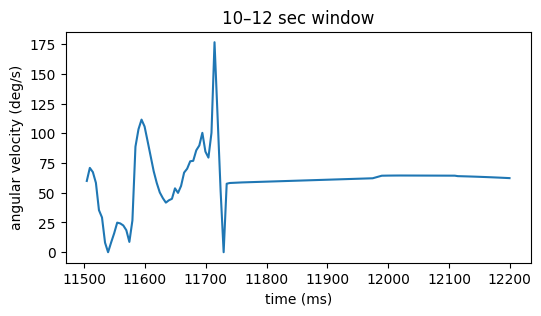

In [22]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 11500) &   # 10 sec
    (df_clean["time_ms"] <= 12200)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

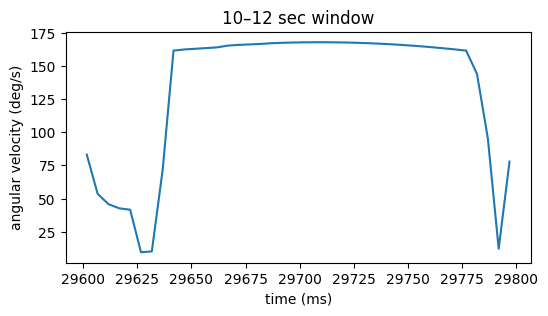

In [23]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 29600) &   # 10 sec
    (df_clean["time_ms"] <= 29800)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

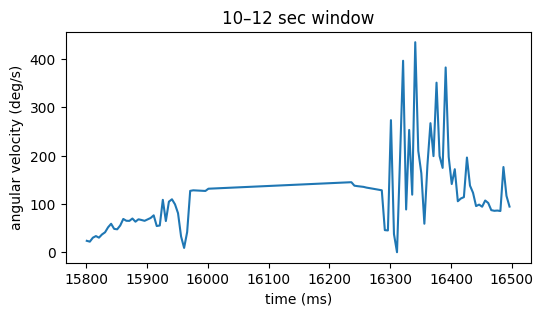

In [24]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 15800) &   # 10 sec
    (df_clean["time_ms"] <= 16500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

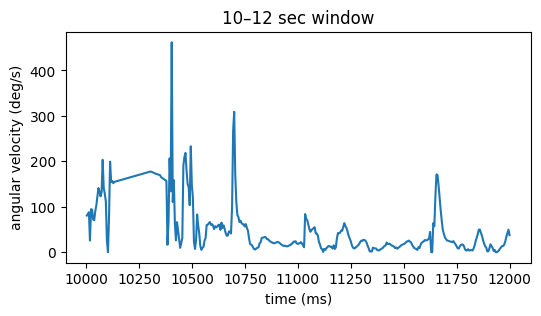

In [25]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 10000) &   # 10 sec
    (df_clean["time_ms"] <= 12000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

# Descriptive Statistics

## Percentage of Interpolation

In [26]:
n_total = len(df_clean)
n_interp = df_clean["is_interpolated"].sum()

pct_interp = 100 * n_interp / n_total

print("\n=== Interpolation stats (FULL dataset) ===")
print(f"Total samples: {n_total}")
print(f"Interpolated samples: {n_interp}")
print(f"Percentage interpolated: {pct_interp:.2f}%")


=== Interpolation stats (FULL dataset) ===
Total samples: 202969
Interpolated samples: 7126
Percentage interpolated: 3.51%


## number of rows with high velocity

In [27]:
THRESHOLD = 800
high_vel = df_clean[df_clean["angular_velocity"] > THRESHOLD]

n_spikes = len(high_vel)
n_total = len(df_clean)

pct = 100 * n_spikes / n_total

print("=== Spike samples ===")
print(f"Total samples: {n_total}")
print(f"Spike samples (> {THRESHOLD}): {n_spikes}")
print(f"Percentage: {pct:.2f}%")

=== Spike samples ===
Total samples: 202969
Spike samples (> 800): 28
Percentage: 0.01%


## Interpolated Segments Durations

In [28]:
# make sure rows are in time order
df_clean = df_clean.sort_values(
    ["condition_number", "trial_number", "gaze_capture_time"]
).copy()

def find_true_runs(x):
    runs = []
    start = None

    for i, val in enumerate(x):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None

    if start is not None:
        runs.append((start, len(x) - 1))

    return runs

segment_rows = []

for (cond, trial), sub in df_clean.groupby(["condition_number", "trial_number"]):
    sub = sub.reset_index(drop=True)

    runs = find_true_runs(sub["is_interpolated"].to_numpy())

    for start, end in runs:
        n_samples = end - start + 1

        start_time = sub.loc[start, "gaze_capture_time"]
        end_time = sub.loc[end, "gaze_capture_time"]

        # duration in ms
        duration_ms = (end_time - start_time) / 1e6

        segment_rows.append({
            "condition_number": cond,
            "trial_number": trial,
            "start_idx": start,
            "end_idx": end,
            "n_samples": n_samples,
            "start_time": start_time,
            "end_time": end_time,
            "duration_ms": duration_ms
        })

interp_segments = pd.DataFrame(segment_rows)

print("=== Interpolated segments ===")
print(f"Number of interpolated segments: {len(interp_segments)}")

print("\n=== Segment length in samples ===")
print(interp_segments["n_samples"].describe())

print("\n=== Segment duration in ms ===")
print(interp_segments["duration_ms"].describe())

=== Interpolated segments ===
Number of interpolated segments: 319

=== Segment length in samples ===
count    319.000000
mean      22.338558
std       29.041254
min        7.000000
25%        7.000000
50%       16.000000
75%       25.000000
max      281.000000
Name: n_samples, dtype: float64

=== Segment duration in ms ===
count     319.000000
mean      203.919445
std       217.358361
min        29.992600
25%        30.007800
50%       155.019500
75%       285.537150
max      1640.209300
Name: duration_ms, dtype: float64


In [29]:
runs = find_runs(seg["is_interpolated"].fillna(False).to_numpy())

print("Number of runs:", len(runs))

for a, b in runs[:5]:
    print(
        (seg["gaze_capture_time"].iloc[b] - seg["gaze_capture_time"].iloc[a]) / 1e6
    )

Number of runs: 17
195.021
470.0591
30.0056
150.0167
135.0279


## Checking the sampling rate after interpolation

In [30]:
df_clean["dt"] = df_clean.groupby(
    ["condition_number", "trial_number"]
)["time_ms"].diff()

In [31]:
df_clean["dt"].describe()

count    202951.000000
mean          5.156031
std           5.418010
min           3.964800
25%           4.999800
50%           5.000600
75%           5.001400
max         485.055300
Name: dt, dtype: float64

In [32]:
t = pd.to_numeric(df_clean["gaze_capture_time"], errors="coerce")

# time difference per row in ns
dt_ns = t.diff()

# sampling rate per row in Hz
df_clean["sampling_rate"] = 1e9 / dt_ns

bad_rows = df_clean[df_clean["sampling_rate"] < 199]

result = bad_rows[
    [
        "gaze_capture_time",
        "sampling_rate",
        "left_status",
        "right_status",
        "angular_velocity_before",
        "angular_velocity",
    ]
]

num_bad = (df_clean["sampling_rate"] < 199).sum()

print(num_bad)
print(result.head(20))

972
        gaze_capture_time  sampling_rate  left_status right_status  \
317   1000325696327863600     166.722241      Tracked  Compensated   
327   1000325696377867300     166.625010      Tracked  Compensated   
551   1000325697503012300     100.008001      Tracked      Invalid   
552   1000325697708036200       4.877480  Compensated      Invalid   
553   1000325697748040600      24.997250      Invalid      Visible   
554   1000325697913065400       6.059695      Visible      Invalid   
1008  1000325700184352200     166.522347      Tracked      Tracked   
1021  1000325700249361900     166.738920      Tracked      Tracked   
1338  1000325701844563900      66.634238      Invalid  Compensated   
1340  1000325701864567800      66.657779      Invalid  Compensated   
1344  1000325701889567900      99.979004      Invalid  Compensated   
1348  1000325701914574900      99.958018      Invalid  Compensated   
1787  1000325704110849400     166.661111      Tracked      Tracked   
2132  1000325705

# Comparing high velocity before and after interpolation

In [33]:
tmp = (
    df_clean
    .sort_values(["condition_number", "trial_number", "gaze_capture_time"])
    .assign(
        dt_ms=lambda d: d.groupby(
            ["condition_number", "trial_number"]
        )["gaze_capture_time"].diff() / 1e6,
        sampling_rate_hz=lambda d: 1000 / d["dt_ms"]
    )
)

In [34]:
high_vel_after = tmp[tmp["angular_velocity"] > 800]
low_sr_after = high_vel_after[high_vel_after["sampling_rate_hz"] < 199]

n_high = len(high_vel_after)
n_low_sr = len(low_sr_after)
pct_low_sr = 100 * n_low_sr / n_high if n_high > 0 else np.nan

print("\n=== High velocity AFTER interpolation ===")
print(f"Count > 800: {n_high}")

print("\n=== Low sampling rate among those ===")
print(f"Count < 199 Hz: {n_low_sr}")
print(f"Percentage: {pct_low_sr:.2f}%")


=== High velocity AFTER interpolation ===
Count > 800: 28

=== Low sampling rate among those ===
Count < 199 Hz: 0
Percentage: 0.00%


In [35]:
high_vel_before = tmp[tmp["angular_velocity_before"] > 800]
low_sr_before = high_vel_before[high_vel_before["sampling_rate_hz"] < 199]

n_high_b = len(high_vel_before)
n_low_sr_b = len(low_sr_before)
pct_low_sr_b = 100 * n_low_sr_b / n_high_b if n_high_b > 0 else np.nan

print("\n=== High velocity BEFORE interpolation ===")
print(f"Count > 800: {n_high_b}")

print("\n=== Low sampling rate among those ===")
print(f"Count < 199 Hz: {n_low_sr_b}")
print(f"Percentage: {pct_low_sr_b:.2f}%")


=== High velocity BEFORE interpolation ===
Count > 800: 1052

=== Low sampling rate among those ===
Count < 199 Hz: 147
Percentage: 13.97%


In [36]:
# direct comparison
print("\n=== COMPARISON ===")
print(f"High velocity count: BEFORE={n_high_b} | AFTER={n_high}")
print(f"Low SR %:           BEFORE={pct_low_sr_b:.2f}% | AFTER={pct_low_sr:.2f}%")


=== COMPARISON ===
High velocity count: BEFORE=1052 | AFTER=28
Low SR %:           BEFORE=13.97% | AFTER=0.00%


In [37]:
vel_col = "angular_velocity"   # or "angular_velocity_before"

tmp = (
    df_clean
    .sort_values(["condition_number", "trial_number", "gaze_capture_time"])
    .copy()
)

tmp["dt_ms"] = (
    tmp.groupby(["condition_number", "trial_number"])["gaze_capture_time"]
    .diff() / 1e6
)

tmp["sampling_rate_hz"] = np.where(
    tmp["dt_ms"] > 0,
    1000 / tmp["dt_ms"],
    np.nan
)

tmp["high_vel"] = tmp[vel_col] > 800

tmp["prev_high"] = (
    tmp.groupby(["condition_number", "trial_number"])["high_vel"]
    .shift(1)
    .astype("boolean")
    .fillna(False)
)

tmp["next_high"] = (
    tmp.groupby(["condition_number", "trial_number"])["high_vel"]
    .shift(-1)
    .astype("boolean")
    .fillna(False)
)

tmp["isolated_high"] = (
    tmp["high_vel"] &
    (~tmp["prev_high"]) &
    (~tmp["next_high"])
)

tmp["prev_interp"] = (
    tmp.groupby(["condition_number", "trial_number"])["is_interpolated"]
    .shift(1)
    .astype("boolean")
    .fillna(False)
)

tmp["next_interp"] = (
    tmp.groupby(["condition_number", "trial_number"])["is_interpolated"]
    .shift(-1)
    .astype("boolean")
    .fillna(False)
)

tmp["near_interpolation"] = (
    tmp["is_interpolated"] |
    tmp["prev_interp"] |
    tmp["next_interp"]
)

isolated = tmp[tmp["isolated_high"]].copy()

print(f"\nVelocity column used: {vel_col}")
print(f"Total isolated spikes: {len(isolated)}")

print("\n=== Isolated spikes near interpolation ===")
print(isolated["near_interpolation"].value_counts(dropna=False))
print(isolated["near_interpolation"].value_counts(normalize=True, dropna=False) * 100)

isolated["before_interp"] = isolated["next_interp"]
isolated["after_interp"] = isolated["prev_interp"]

print("\n=== Before interpolation ===")
print(isolated["before_interp"].sum())

print("\n=== After interpolation ===")
print(isolated["after_interp"].sum())

print("\n=== Example isolated spikes ===")
print(isolated[[
    "gaze_capture_time",
    vel_col,
    "dt_ms",
    "sampling_rate_hz",
    "is_interpolated",
    "prev_interp",
    "next_interp",
    "left_status",
    "right_status"
]].head(20).to_string(index=False))


Velocity column used: angular_velocity
Total isolated spikes: 14

=== Isolated spikes near interpolation ===
near_interpolation
False    13
True      1
Name: count, dtype: Int64
near_interpolation
False    92.857143
True      7.142857
Name: proportion, dtype: Float64

=== Before interpolation ===
1

=== After interpolation ===
0

=== Example isolated spikes ===
  gaze_capture_time  angular_velocity    dt_ms  sampling_rate_hz  is_interpolated  prev_interp  next_interp left_status right_status
1000325972713909200        923.980969 5.000576        199.976963            False        False        False Compensated  Compensated
1000326013790115300        803.911553 5.000576        199.976963            False        False        False     Tracked      Tracked
1000326103174451400        843.379597 5.000576        199.976963            False        False        False Compensated  Compensated
1000327013114889300        838.628899 5.007872        199.685615            False        False        F

## Plots of Spikes before and after preprocessing

In [38]:
def plot_spike_before_after(
    df_trial: pd.DataFrame,
    center_idx: int,
    pad: int = 20,
    before_col: str = "angular_velocity_before",
    after_col: str = "angular_velocity",
):
    """
    Plot angular velocity before vs after interpolation around one spike.
    """
    sub = (
        df_trial
        .sort_values("gaze_capture_time")
        .reset_index(drop=True)
        .copy()
    )

    # normalize time so trial starts at 0 ms
    sub["time_ms"] = (
        sub["gaze_capture_time"] - sub["gaze_capture_time"].iloc[0]
    ) / 1e6

    a = max(0, center_idx - pad)
    b = min(len(sub) - 1, center_idx + pad)
    win = sub.iloc[a:b+1].copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(win["time_ms"], win[before_col], label="before interpolation")
    ax.plot(win["time_ms"], win[after_col], label="after interpolation")

    # mark each interpolated run separately
    interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
    runs = find_runs(interp_mask)

    first_span = True
    for r0, r1 in runs:
        t0 = win["time_ms"].iloc[r0]
        t1 = win["time_ms"].iloc[r1]
        if first_span:
            ax.axvspan(t0, t1, alpha=0.2, label="interpolated region")
            first_span = False
        else:
            ax.axvspan(t0, t1, alpha=0.2)

    # mark chosen spike center
    spike_t = sub.loc[center_idx, "time_ms"]
    ax.axvline(spike_t, linestyle="--", alpha=0.7, label="spike center")

    cond = sub["condition_number"].iloc[0]
    trial = sub["trial_number"].iloc[0]

    ax.set_title(f"Condition {cond}, Trial {trial}, center idx {center_idx}")
    ax.set_xlabel("time (ms)")
    ax.set_ylabel("angular velocity (deg/s)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [39]:
# find spike centers from different trials
def get_spike_examples_from_different_trials(
    df: pd.DataFrame,
    mode: str = "after",          # "after", "before", or "changed"
    threshold: float = 800,
    delta_threshold: float = 300,
    max_plots: int = 10,
):
    """
    Return up to max_plots spike examples from different trials.

    mode="after"   -> choose rows where angular_velocity > threshold
    mode="before"  -> choose rows where angular_velocity_before > threshold
    mode="changed" -> choose rows where abs(after - before) > delta_threshold
    """
    tmp = (
        df.sort_values(["condition_number", "trial_number", "gaze_capture_time"])
          .reset_index(drop=False)   # keep original index just in case
          .copy()
    )

    if mode == "after":
        cand = tmp[tmp["angular_velocity"] > threshold].copy()
        cand["score"] = cand["angular_velocity"]
    elif mode == "before":
        cand = tmp[tmp["angular_velocity_before"] > threshold].copy()
        cand["score"] = cand["angular_velocity_before"]
    elif mode == "changed":
        cand = tmp.copy() 
        cand["delta_abs"] = (
            cand["angular_velocity"] - cand["angular_velocity_before"]
        ).abs()
        cand = cand[cand["delta_abs"] > delta_threshold].copy()
        cand["score"] = cand["delta_abs"]
    else:
        raise ValueError("mode must be 'after', 'before', or 'changed'")

    # biggest spikes first
    cand = cand.sort_values("score", ascending=False)

    chosen = []
    used_trials = set()

    for _, row in cand.iterrows():
        key = (row["condition_number"], row["trial_number"])
        if key in used_trials:
            continue

        # get row position within its trial after sorting
        trial_df = (
            df[
                (df["condition_number"] == row["condition_number"]) &
                (df["trial_number"] == row["trial_number"])
            ]
            .sort_values("gaze_capture_time")
            .reset_index(drop=True)
        )

        # find matching row inside that trial by timestamp
        matches = np.where(trial_df["gaze_capture_time"].to_numpy() == row["gaze_capture_time"])[0]
        if len(matches) == 0:
            continue

        center_idx = int(matches[0])

        chosen.append({
            "condition_number": row["condition_number"],
            "trial_number": row["trial_number"],
            "gaze_capture_time": row["gaze_capture_time"],
            "center_idx": center_idx,
            "score": row["score"],
        })
        used_trials.add(key)

        if len(chosen) >= max_plots:
            break

    return chosen

In [40]:
# plot 10 spike examples
def plot_multiple_spike_examples(
    df: pd.DataFrame,
    examples: list,
    pad: int = 20,
    before_col: str = "angular_velocity_before",
    after_col: str = "angular_velocity",
):
    """
    Plot a list of spike examples, one plot per trial.
    """
    if not examples:
        print("No spike examples found.")
        return

    for ex in examples:
        trial_df = df[
            (df["condition_number"] == ex["condition_number"]) &
            (df["trial_number"] == ex["trial_number"])
        ].copy()

        plot_spike_before_after(
            trial_df,
            center_idx=ex["center_idx"],
            pad=pad,
            before_col=before_col,
            after_col=after_col,
        )

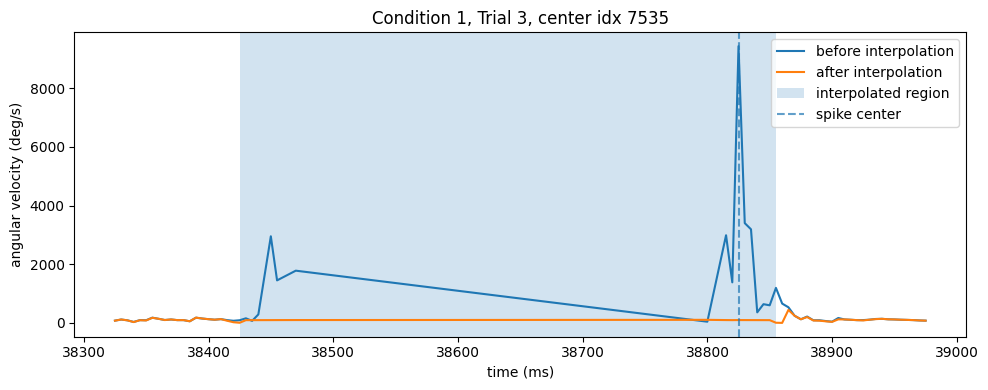

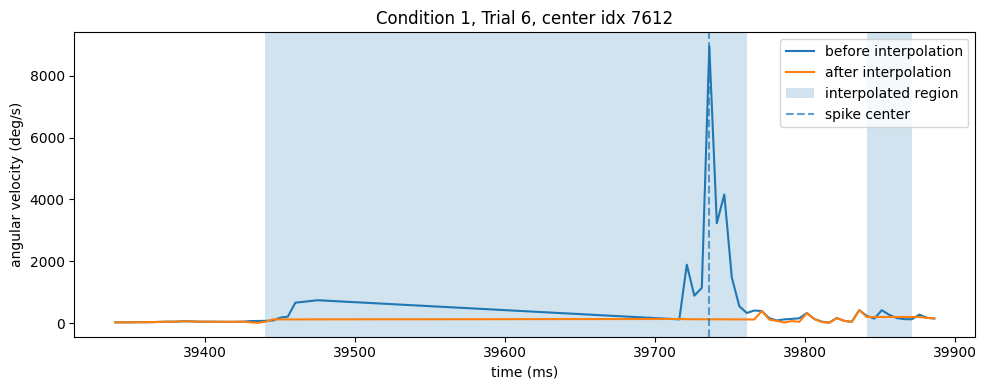

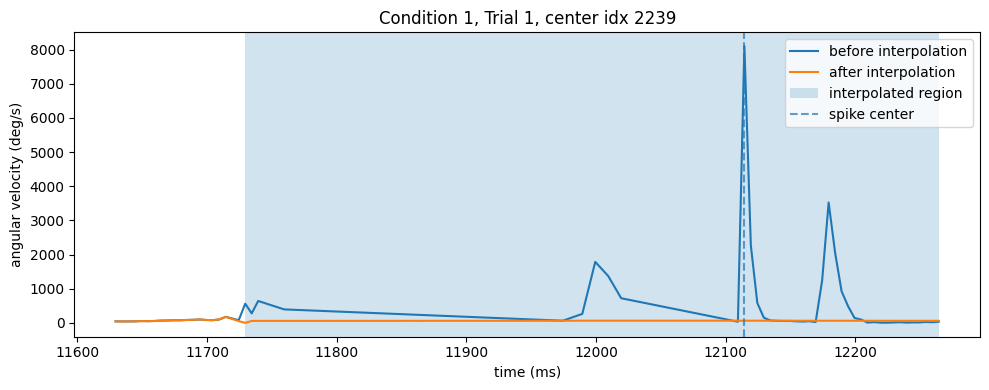

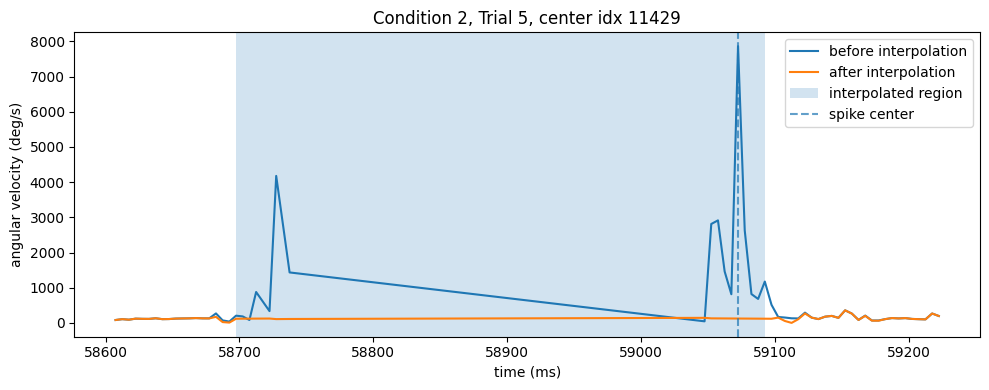

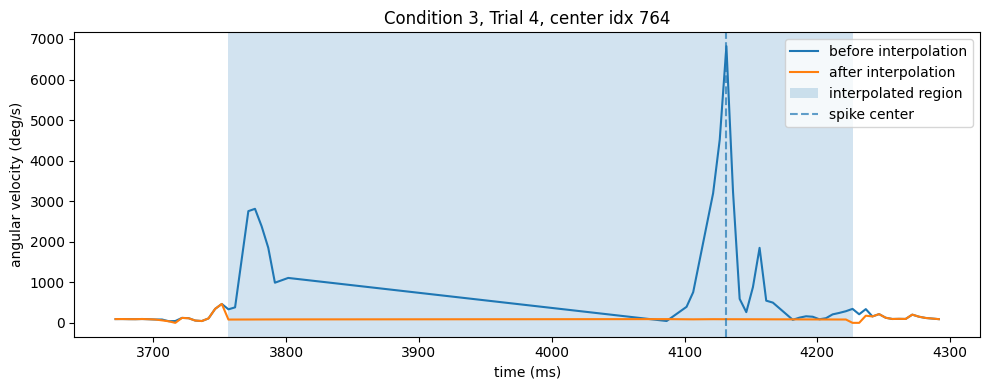

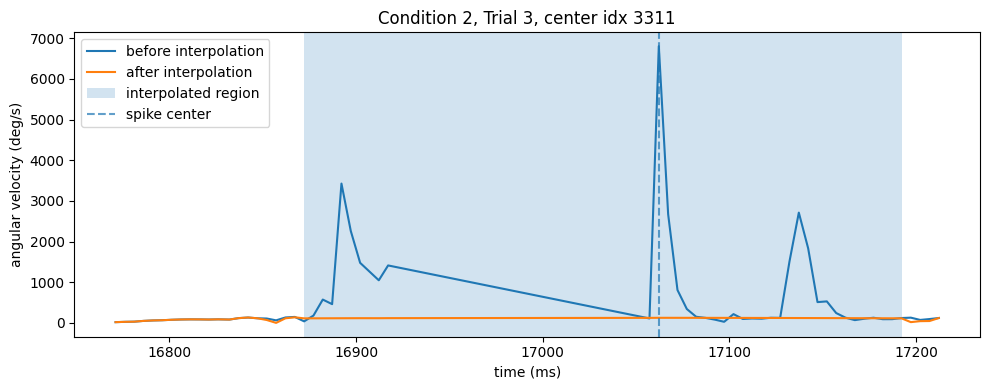

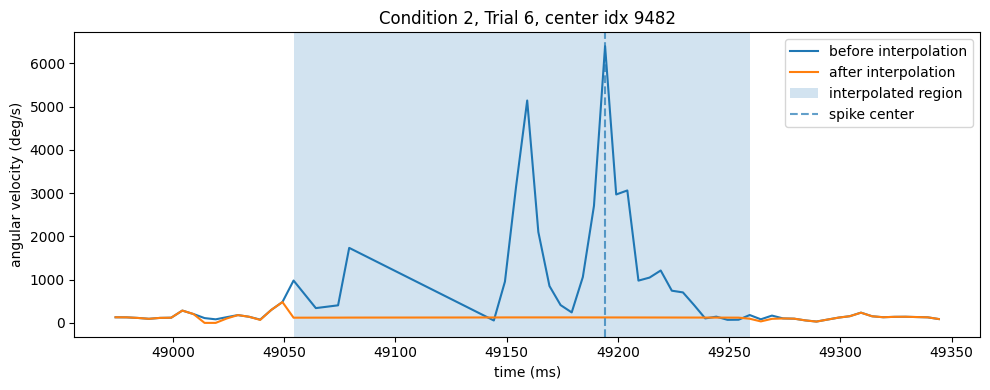

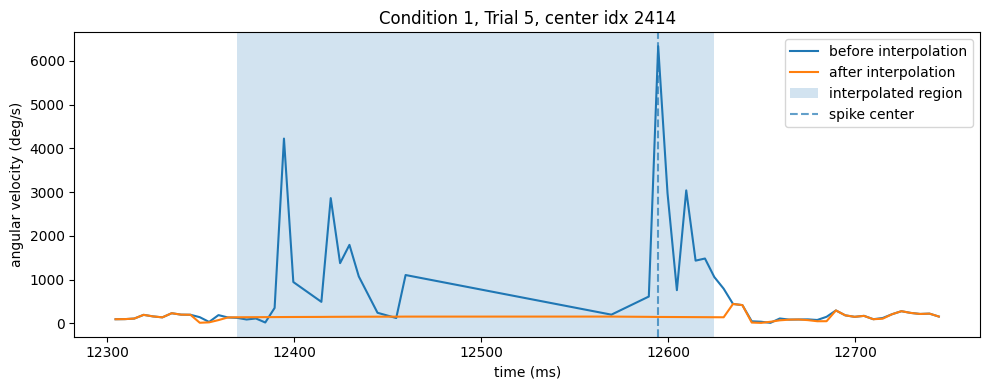

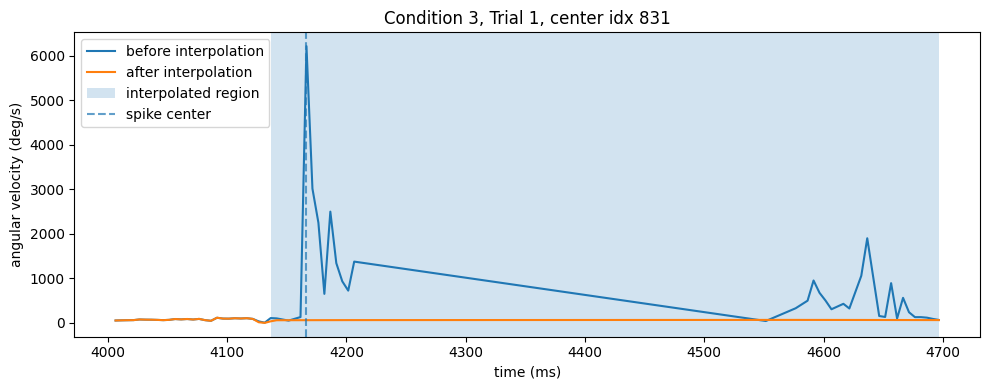

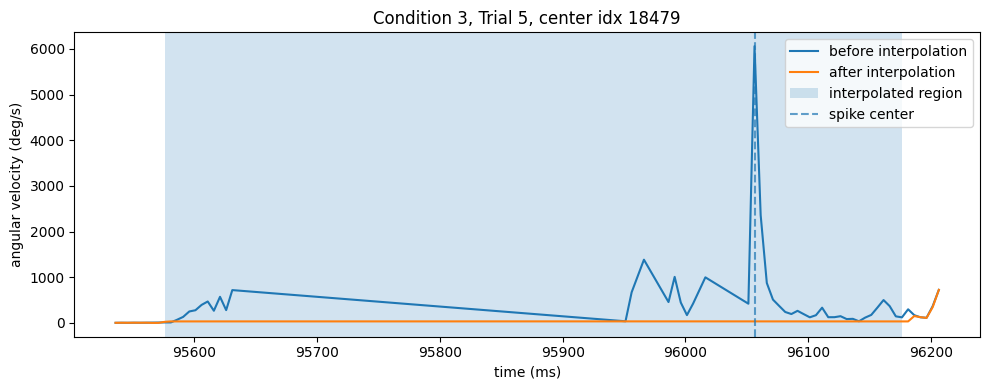

In [41]:
examples_changed = get_spike_examples_from_different_trials(
    df_clean,
    mode="changed",
    delta_threshold=300,
    max_plots=10,
)

plot_multiple_spike_examples(df_clean, examples_changed, pad=30)

### 5 random 30s segments after interpolation look like this

In [42]:
def plot_5_random_segments(df, vel_col="angular_velocity"):
    fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=False)

    trials = df[["condition_number", "trial_number"]].drop_duplicates()

    for ax in axes:
        # pick random trial
        row = trials.sample(1).iloc[0]
        cond = row["condition_number"]
        trial = row["trial_number"]

        sub = (
            df[
                (df["condition_number"] == cond) &
                (df["trial_number"] == trial)
            ]
            .sort_values("gaze_capture_time")
            .reset_index(drop=True)
            .copy()
        )

        sub["time_s"] = sub["gaze_capture_time"] / 1e9

        t_min = sub["time_s"].min()
        t_max = sub["time_s"].max()

        # pick 30s window
        if (t_max - t_min) < 30:
            win = sub.copy()
        else:
            start = np.random.uniform(t_min, t_max - 30)
            end = start + 30
            win = sub[(sub["time_s"] >= start) & (sub["time_s"] <= end)].copy()

        win = win.reset_index(drop=True)

        ax.plot(win["time_s"], win[vel_col], label="angular velocity")

        # highlight each interpolated run separately
        interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
        runs = find_runs(interp_mask)

        for a, b in runs:
            t0 = win["time_s"].iloc[a]
            t1 = win["time_s"].iloc[b]
            ax.axvspan(t0, t1, alpha=0.2)

        ax.set_title(f"Cond {cond}, Trial {trial}")
        ax.set_ylabel("deg/s")
        ax.legend()

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

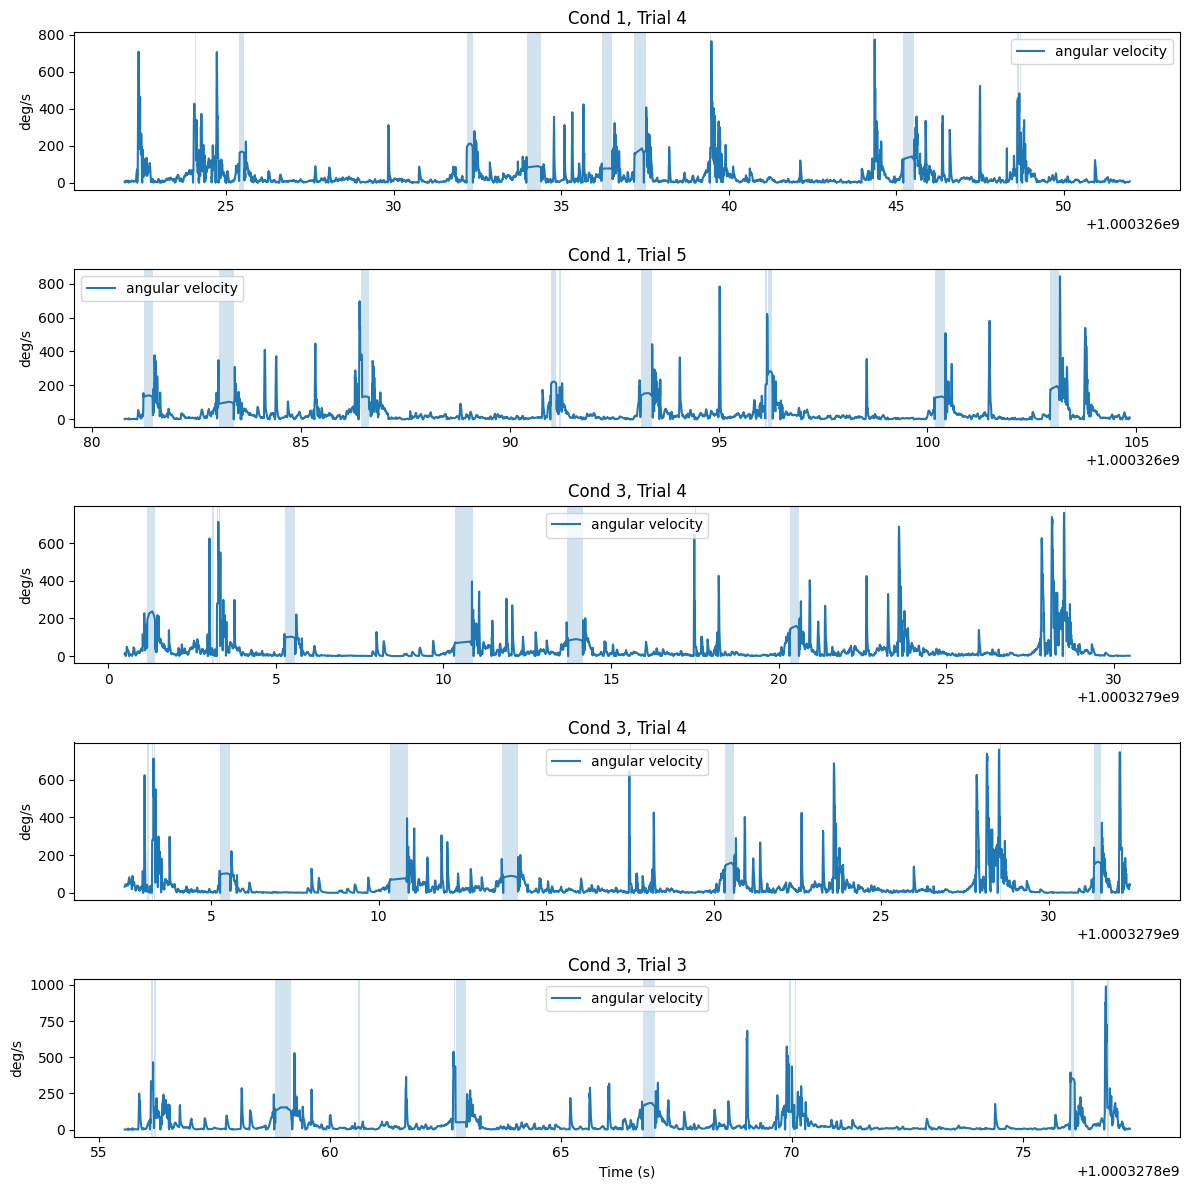

In [43]:
plot_5_random_segments(df_clean)

# Velocity Category

In [95]:
# --------------------------------------------------
# Angular velocity + MAD threshold + categorization
# Everything uses df_clean
# --------------------------------------------------

import numpy as np
import pandas as pd


# --------------------------------------------------
# Angular velocity
# --------------------------------------------------

def add_angular_velocity(df_clean, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from clean_gaze_forward vectors.
    """

    df_clean = df_clean.copy()

    group_cols = ["condition_number", "trial_number"]
    sort_cols = ["condition_number", "trial_number", time_col]

    if "participant_id" in df_clean.columns:
        group_cols = ["participant_id", "condition_number", "trial_number"]
        sort_cols = ["participant_id", "condition_number", "trial_number", time_col]

    df_clean = df_clean.sort_values(sort_cols)

    df_clean["angular_velocity"] = np.nan

    for _, sub in df_clean.groupby(group_cols, sort=False):
        idx = sub.index

        g = sub[
            [
                "clean_gaze_forward_x",
                "clean_gaze_forward_y",
                "clean_gaze_forward_z",
            ]
        ].to_numpy(dtype=float)

        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        g_prev = g[:-1]
        g_curr = g[1:]

        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        dot_prod = np.clip(dot_prod, -1.0, 1.0)

        angles_rad = np.arctan2(cross_norm, dot_prod)

        t = pd.to_numeric(sub[time_col], errors="coerce").to_numpy(dtype=float)
        dt = np.diff(t) * 1e-9

        vel = np.full(len(sub), np.nan)

        valid = np.isfinite(dt) & (dt > 0) & np.isfinite(angles_rad)

        vel_indices = np.where(valid)[0] + 1
        vel[vel_indices] = np.degrees(angles_rad[valid] / dt[valid])

        df_clean.loc[idx, "angular_velocity"] = vel

    return df_clean


# --------------------------------------------------
# MAD threshold
# --------------------------------------------------

def at_mad_threshold(
    angular_vel,
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50
):
    """
    Compute one adaptive saccade threshold from angular velocity using MAD.
    """

    v = pd.to_numeric(pd.Series(angular_vel), errors="coerce").to_numpy(dtype=float)
    v = np.abs(v)
    v = v[np.isfinite(v)]

    if len(v) < min_samples:
        return np.nan, []

    threshs = []
    current_th = float(th_0)

    for _ in range(max_iter):
        threshs.append(current_th)

        subset = v[v < current_th]

        if len(subset) < min_samples:
            return np.nan, threshs

        median = np.median(subset)
        mad = np.median(np.abs(subset - median))

        next_th = median + 3.0 * 1.486 * mad

        if not np.isfinite(next_th):
            return np.nan, threshs

        if abs(current_th - next_th) <= tol:
            threshs.append(float(next_th))
            return float(next_th), threshs

        current_th = float(next_th)

    return float(current_th), threshs


def compute_global_mad_threshold(
    df_clean,
    vel_col="angular_velocity",
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50,
):
    """
    Compute one MAD-based threshold across all rows of df_clean.
    """

    threshold, trace = at_mad_threshold(
        df_clean[vel_col],
        th_0=th_0,
        min_samples=min_samples,
        tol=tol,
        max_iter=max_iter,
    )

    vel = pd.to_numeric(df_clean[vel_col], errors="coerce").abs()

    threshold_summary = pd.DataFrame({
        "velocity_column": [vel_col],
        "mad_threshold": [threshold],
        "n_total_rows": [len(df_clean)],
        "n_valid_velocity_samples": [int(vel.notna().sum())],
        "min_velocity": [vel.min()],
        "median_velocity": [vel.median()],
        "mean_velocity": [vel.mean()],
        "max_velocity": [vel.max()],
        "threshold_trace": [trace],
    })

    return threshold, threshold_summary


def add_global_mad_threshold(
    df_clean,
    threshold,
    threshold_col="mad_threshold"
):
    """
    Add MAD threshold to df_clean.
    """

    df_clean = df_clean.copy()
    df_clean[threshold_col] = threshold
    return df_clean


# --------------------------------------------------
# Classify fixation / saccade
# --------------------------------------------------

def add_velocity_category(
    df_clean,
    vel_col="angular_velocity",
    threshold_col="mad_threshold",
    category_col="velocity_category",
):
    """
    Label each sample as fixation or saccade.

    Rules:
    - fixation: abs(angular_velocity) < mad_threshold
    - saccade:  abs(angular_velocity) >= mad_threshold
    - <NA>:      missing velocity or threshold
    """

    df_clean = df_clean.copy()

    if vel_col not in df_clean.columns:
        raise KeyError(f"Column '{vel_col}' not found. Run add_angular_velocity(df_clean) first.")

    if threshold_col not in df_clean.columns:
        raise KeyError(f"Column '{threshold_col}' not found. Add MAD threshold first.")

    vel = pd.to_numeric(df_clean[vel_col], errors="coerce").abs()
    thr = pd.to_numeric(df_clean[threshold_col], errors="coerce")

    df_clean[category_col] = pd.Series(pd.NA, index=df_clean.index, dtype="string")

    valid = vel.notna() & thr.notna()

    df_clean.loc[valid & (vel < thr), category_col] = "fixation"
    df_clean.loc[valid & (vel >= thr), category_col] = "saccade"

    return df_clean


# --------------------------------------------------
# Run everything on df_clean
# --------------------------------------------------

df_clean = add_angular_velocity(
    df_clean,
    time_col="gaze_capture_time"
)

global_threshold, threshold_summary = compute_global_mad_threshold(
    df_clean,
    vel_col="angular_velocity",
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50
)

df_clean = add_global_mad_threshold(
    df_clean,
    global_threshold,
    threshold_col="mad_threshold"
)

df_clean = add_velocity_category(
    df_clean,
    vel_col="angular_velocity",
    threshold_col="mad_threshold",
    category_col="velocity_category"
)

print("Global MAD threshold:", global_threshold)
display(threshold_summary)

print("\nOverall velocity category counts:")
display(df_clean["velocity_category"].value_counts(dropna=False).to_frame("count"))

Global MAD threshold: 35.04124919108884


,velocity_column,mad_threshold,n_total_rows,n_valid_velocity_samples,min_velocity,median_velocity,mean_velocity,max_velocity,threshold_trace
0,angular_velocity,35.041249,202969,202951,0.0,13.351964,35.680761,1147.983934,"[200.0, 54.45656487350456, 41.296299270695286,..."



Overall velocity category counts:


,count
velocity_category,
fixation,153936
saccade,49015
<NA>,18


In [96]:
df_clean = add_velocity_category(df_clean)

In [97]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,gaze_origin_y,gaze_origin_z,left_forward_x,left_forward_y,left_forward_z,left_origin_x,left_origin_y,left_origin_z,left_status,left_pupil_diameter,left_iris_diameter,left_pupil_iris_ratio,left_eye_openness,right_forward_x,right_forward_y,right_forward_z,right_origin_x,right_origin_y,right_origin_z,right_status,right_pupil_diameter,right_iris_diameter,right_pupil_iris_ratio,right_eye_openness,inter_pupillary_distance,hmd_position_x,hmd_position_y,hmd_position_z,hmd_rotation_x,hmd_rotation_y,hmd_rotation_z,hmd_rotation_w,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality,condition_number,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_velocity_before,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,dt,sampling_rate,velocity_category,hit_obj_group,mad_threshold
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,0,0,0,0.047548,0.143904,0.988449,-0.033577,0,0,Tracked,4.820606,12.65099,0.381046,1.000000,-0.021272,0.144035,0.989344,0.033577,0,0,Tracked,5.292973,12.58795,0.420479,0.973268,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,NaN,NaN,<NA>,walls,35.041249
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,0,0,0,0.047397,0.144022,0.988439,-0.033577,0,0,Tracked,4.815219,12.65099,0.380620,1.000000,-0.021240,0.144152,0.989328,0.033577,0,0,Tracked,5.293125,12.58795,0.420491,0.973297,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.420650,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653460,5.0002,199.992000,fixation,walls,35.041249
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,0,0,0,0.047250,0.144130,0.988430,-0.033577,0,0,Tracked,4.812161,12.65099,0.380378,1.000000,-0.021218,0.144258,0.989313,0.033577,0,0,Tracked,5.294265,12.58795,0.420582,0.973327,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.307756,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653879,4.9970,200.120072,fixation,walls,35.041249
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,0,0,0,0.047095,0.144188,0.988429,-0.033577,0,0,Tracked,4.808924,12.65099,0.380122,1.000000,-0.021184,0.144316,0.989305,0.033577,0,0,Tracked,5.295160,12.58795,0.420653,0.973373,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.791661,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791676,5.0008,199.968005,fixation,walls,35.041249
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,0,0,0,0.046948,0.144232,0.988429,-0.033577,0,0,Tracked,4.806955,12.65099,0.379967,1.000000,-0.021160,0.144359,0.989299,0.033577,0,0,Tracked,5.296308,12.58795,0.420744,0.973384,67.200,0.352550,1.598016,0.020432,0.079370,0.704137,-0.074286,0.701693,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,0.664515,True,False,False,0.012964,0.144336,0.98944

## grouping collidars

In [98]:
import re
import numpy as np
import pandas as pd
from collections import defaultdict

In [99]:
def get_object_group(name):
    """
    Convert raw collider/object name into a grouped analysis label.

    Keeps:
    - bricks and their studs grouped by status + ID: res_010, temp_010, dis_010
    - board / board studs grouped as board
    - walls/floor/ceiling grouped as walls
    - desks and model plate as their own groups
    """

    if pd.isna(name):
        return np.nan

    name = str(name)

    # -------------------------
    # Desks / model plate
    # -------------------------
    if name == "model_desk_base":
        return "model_desk_base"

    if name == "resource_desk_base":
        return "resource_desk_base"

    if name == "work_desk_base":
        return "work_desk_base"

    if name == "Model_plate":
        return "model_plate"

    # -------------------------
    # Brick bodies and brick studs
    # -------------------------
    m = re.search(r'_(res|temp|dis)_(\d+)', name)

    if m:
        status = m.group(1)
        brick_id = m.group(2)
        return f"{status}_{brick_id}"

    # -------------------------
    # Board and board studs
    # -------------------------
    if (
        re.match(r'board_stud_top_\d+', name)
        or name == "Lego_Board_10x10"
        or "Board" in name
    ):
        return "board"

    # -------------------------
    # Walls / room / environment
    # -------------------------
    if (
        re.match(r'Wall_', name)
        or name in ["Ceiling", "Floor", "PlaneLeft", "PlaneRight"]
    ):
        return "walls"

    return name

In [100]:
df_clean["hit_obj_group"] = df_clean["hit_obj_name"].apply(get_object_group)

In [101]:
df_clean[["hit_obj_name", "hit_obj_group"]].drop_duplicates().head(30)

,hit_obj_name,hit_obj_group
0,Wall_Front,walls
344,Wall_Left,walls
355,model_desk_base,model_desk_base
356,Model_plate,model_plate
359,brick_2x2_pink_temp_010,temp_010
360,brick_2x2_green_temp_012,temp_012
362,brick_2x2_green_temp_009,temp_009
414,brick_2x2_pink_temp_011,temp_011
550,Floor,walls
552,Wall_Cut,walls


# Checking fixation stability

In [102]:
def check_fixation_group_dominance(
    df_clean,
    dominance_threshold=0.70,
    min_duration_ms=50,
    group_col="hit_obj_group"
):
    """
    For each fixation segment, check which grouped object dominates.

    Instead of checking raw hit_obj_name, this checks grouped objects:
    - all studs of one brick + brick body are one group
    - all board studs + board are one group
    - all walls are one group
    """

    df = df_clean.copy().sort_values(
        ["condition_number", "trial_number", "time_ms"]
    )

    # Make grouped object column if it does not already exist
    if group_col not in df.columns:
        df[group_col] = df["hit_obj_name"].apply(get_object_group)

    # Label contiguous runs of same velocity category
    df["run_id"] = (
        (df["velocity_category"] != df["velocity_category"].shift()) |
        (df["condition_number"] != df["condition_number"].shift()) |
        (df["trial_number"] != df["trial_number"].shift())
    ).cumsum()

    results = []

    fixation_runs = df[df["velocity_category"] == "fixation"].groupby("run_id")

    for run_id, group in fixation_runs:
        duration_ms = group["time_ms"].max() - group["time_ms"].min()

        if duration_ms < min_duration_ms:
            continue

        looked_groups = group[group_col].dropna()
        n_named = len(looked_groups)

        if n_named == 0:
            dominant_group = None
            dominance = np.nan
            stable = False
            n_unique_groups = 0
        else:
            counts = looked_groups.value_counts()
            dominant_group = counts.index[0]
            dominance = counts.iloc[0] / n_named
            stable = dominance >= dominance_threshold
            n_unique_groups = looked_groups.nunique()

        result = {
            "run_id": run_id,
            "condition_number": group["condition_number"].iloc[0],
            "trial_number": group["trial_number"].iloc[0],
            "start_time_ms": group["time_ms"].min(),
            "end_time_ms": group["time_ms"].max(),
            "duration_ms": duration_ms,
            "n_samples": len(group),

            "dominant_group": dominant_group,
            "dominance_ratio": dominance,
            "n_unique_groups": n_unique_groups,
            "stable": stable,
        }

        # Add focus distance if available
        if "focus_distance" in group.columns:
            result["focus_distance_mean"] = group["focus_distance"].mean()
            result["focus_distance_median"] = group["focus_distance"].median()

        results.append(result)

    return pd.DataFrame(results)

In [131]:
stability_df = check_fixation_group_dominance(
    df_clean,
    dominance_threshold=0.70,
    min_duration_ms=50
)

stability_df

,run_id,condition_number,trial_number,start_time_ms,end_time_ms,duration_ms,n_samples,dominant_group,dominance_ratio,n_unique_groups,stable,focus_distance_mean,focus_distance_median
0,1,1,1,9.9972,330.0354,320.0382,65,walls,1.000000,1,True,0.996337,0.995680
1,3,1,1,405.0466,560.0667,155.0201,32,walls,1.000000,1,True,0.850335,0.850688
2,5,1,1,620.0738,720.0876,100.0138,21,walls,1.000000,1,True,1.114691,1.115806
3,9,1,1,800.0960,905.1175,105.0215,22,walls,1.000000,1,True,0.857667,0.860544
4,13,1,1,975.1174,1110.1381,135.0207,28,walls,1.000000,1,True,0.744682,0.744951
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119,9269,3,6,94957.0506,95572.1370,615.0864,124,temp_76,0.645161,3,False,0.896435,0.907223
2120,9281,3,6,96267.2156,96522.2490,255.0334,52,board,0.826923,2,True,0.612522,0.589714
2121,9283,3,6,96577.2575,96772.2791,195.0216,40,res_073,0.875000,2,True,0.717722,0.722489
2122,9293,3,6,97117.3202,97332.3535,215.0333,44,NextItemButton,1.000000,1,True,0.623910,0.604525


In [104]:
# 1. Overall stability rate
total = len(stability_df)
stable = stability_df["stable"].sum()
print(f"Stable fixation runs: {stable}/{total} ({100*stable/total:.1f}%)")
print(f"Mean dominance ratio: {stability_df['dominance_ratio'].mean():.3f}")
print()

# 2. Summary table — look at the unstable ones specifically
unstable_df = (
    stability_df[~stability_df["stable"]]
    .sort_values("dominance_ratio")
    .reset_index(drop=True)
)

unstable_df

Stable fixation runs: 1865/2124 (87.8%)
Mean dominance ratio: 0.867



,run_id,condition_number,trial_number,start_time_ms,end_time_ms,duration_ms,n_samples,dominant_group,dominance_ratio,n_unique_groups,stable,focus_distance_mean,focus_distance_median
0,858,1,2,69826.8500,71078.0095,1251.1595,207,board,0.285024,7,False,1.517586,2.000000
1,4962,2,5,8048.0158,9253.1693,1205.1535,242,model_plate,0.305785,4,False,0.681466,0.671201
2,7862,3,5,45436.7627,45801.8143,365.0516,74,model_plate,0.310811,4,False,0.934986,0.929574
3,562,1,2,34243.3389,34768.4069,525.0680,106,temp_111,0.320755,6,False,1.082224,1.097552
4,1179,1,3,1995.2503,2905.3674,910.1171,183,temp_046,0.333333,4,False,0.872194,0.863266
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,7038,3,3,13775.7571,14030.7814,255.0243,52,res_018,0.596154,2,False,0.497044,0.497259
255,4091,2,3,29106.6941,30081.8189,975.1248,196,temp_033,0.596939,3,False,0.674119,0.668314
256,9221,3,6,86789.0142,87169.0609,380.0467,77,res_074,0.597403,2,False,0.672688,0.668758
257,5308,2,5,55060.9813,55441.0306,380.0493,77,temp_077,0.597403,3,False,1.033038,1.066689


In [107]:
# See which object names appear most in unstable runs — 
unstable = stability_df[~stability_df["stable"]]
print(unstable["dominant_group"].value_counts().head(20))

dominant_group
resource_desk_base    26
model_plate           16
board                 16
res_027                5
temp_101               5
res_114                4
temp_120               4
temp_033               4
res_038                4
temp_103               4
res_070                4
res_115                3
dis_014                3
res_031                3
temp_078               3
res_078                3
res_095                3
res_008                3
res_098                3
res_009                2
Name: count, dtype: int64


In [136]:
def summarize_focus_distance(stability_df, unstable_df, col="focus_distance_mean"):
    summary = pd.DataFrame({
        "stable": stability_df[col].describe(),
        "unstable": unstable_df[col].describe()
    })

    return summary

focus_summary = summarize_focus_distance(stability_df, unstable_df)

focus_summary

,stable,unstable
count,2124.000000,259.000000
mean,0.736757,0.810400
std,0.318568,0.326525
min,0.309400,0.413268
25%,0.519282,0.563222
50%,0.650076,0.763183
75%,0.856687,0.936621
max,2.000000,2.000000


## a plot to show how hit object name changes during saccade and fixation

In [108]:
df_clean["velocity_category"].value_counts(dropna=False)

velocity_category
fixation    153936
saccade      49015
<NA>            18
Name: count, dtype: Int64

In [119]:
def find_interesting_mixed_window(
    df,
    condition_number=1,
    trial_number=3,
    time_col="gaze_capture_time",
    category_col="velocity_category",
    obj_col="hit_obj_group",
    window_ms=2500,          # 2.5 seconds by default
    step_ms=500,             # move window every 0.5 sec
    min_fixation_samples=5,
    min_saccade_samples=5,
):
    """
    Find an interesting 2–3 second window containing both fixation and saccade samples.

    The selected window is scored by:
    - number of hit_obj_group changes
    - number of unique hit_obj_group values
    - number of velocity category changes

    It does NOT require fixation -> saccade -> fixation.
    It only requires both fixation and saccade to be present.
    """

    seg = df[
        (df["condition_number"] == condition_number) &
        (df["trial_number"] == trial_number)
    ].copy()

    if seg.empty:
        print("No data found for this condition/trial.")
        return None, None

    seg = seg.sort_values(time_col).reset_index(drop=True)

    # Convert timestamp to ms from trial start
    t = pd.to_numeric(seg[time_col], errors="coerce")
    seg["time_ms"] = (t - t.min()) / 1e6

    # Keep only fixation/saccade
    seg[category_col] = seg[category_col].astype(str).str.strip().str.lower()
    seg = seg[seg[category_col].isin(["fixation", "saccade"])].copy()

    if seg.empty:
        print("No fixation/saccade samples found after filtering.")
        return None, None

    if obj_col not in seg.columns:
        seg[obj_col] = seg["hit_obj_name"].apply(get_object_group)

    seg[obj_col] = seg[obj_col].fillna("No hit").astype(str)

    print("Velocity categories in this condition/trial:")
    display(seg[category_col].value_counts().to_frame("count"))

    candidates = []

    trial_start = seg["time_ms"].min()
    trial_end = seg["time_ms"].max()

    start = trial_start

    while start + window_ms <= trial_end:
        end = start + window_ms

        window = seg[
            (seg["time_ms"] >= start) &
            (seg["time_ms"] <= end)
        ].copy()

        if window.empty:
            start += step_ms
            continue

        n_fix = (window[category_col] == "fixation").sum()
        n_sac = (window[category_col] == "saccade").sum()

        # Require both fixation and saccade
        if n_fix < min_fixation_samples or n_sac < min_saccade_samples:
            start += step_ms
            continue

        n_unique_groups = window[obj_col].nunique()

        n_group_changes = (
            window[obj_col] != window[obj_col].shift()
        ).sum() - 1
        n_group_changes = max(n_group_changes, 0)

        n_category_changes = (
            window[category_col] != window[category_col].shift()
        ).sum() - 1
        n_category_changes = max(n_category_changes, 0)

        score = (
            n_group_changes
            + n_unique_groups
            + n_category_changes
        )

        candidates.append({
            "start_ms": start,
            "end_ms": end,
            "window_ms": window_ms,
            "score": score,
            "n_fixation_samples": n_fix,
            "n_saccade_samples": n_sac,
            "n_unique_groups": n_unique_groups,
            "n_group_changes": n_group_changes,
            "n_category_changes": n_category_changes,
            "total_samples": len(window),
        })

        start += step_ms

    if len(candidates) == 0:
        print("No mixed fixation/saccade window found.")
        return None, None

    candidates_df = pd.DataFrame(candidates).sort_values(
        [
            "score",
            "n_category_changes",
            "n_group_changes",
            "n_unique_groups"
        ],
        ascending=False
    ).reset_index(drop=True)

    best = candidates_df.iloc[0]

    selected_segment = seg[
        (seg["time_ms"] >= best["start_ms"]) &
        (seg["time_ms"] <= best["end_ms"])
    ].copy()

    return selected_segment, candidates_df

In [120]:
def plot_mixed_fixation_saccade_window(
    df,
    condition_number=1,
    trial_number=3,
    time_col="gaze_capture_time",
    category_col="velocity_category",
    obj_col="hit_obj_group",
    window_ms=2500,
    step_ms=500,
    min_fixation_samples=5,
    min_saccade_samples=5,
):
    """
    Plot an interesting 2–3 second window containing both fixation and saccade samples.
    Points are colored by hit_obj_group.
    """

    segment, candidates = find_interesting_mixed_window(
        df=df,
        condition_number=condition_number,
        trial_number=trial_number,
        time_col=time_col,
        category_col=category_col,
        obj_col=obj_col,
        window_ms=window_ms,
        step_ms=step_ms,
        min_fixation_samples=min_fixation_samples,
        min_saccade_samples=min_saccade_samples,
    )

    if segment is None or candidates is None:
        print("Nothing to plot.")
        return None, None, None

    segment = segment.copy()

    # Time starts from 0 inside selected window
    start_ms = segment["time_ms"].min()
    segment["plot_time_ms"] = segment["time_ms"] - start_ms

    # Map fixation/saccade to y-axis
    y_map = {
        "fixation": 0,
        "saccade": 1
    }
    segment["y"] = segment[category_col].map(y_map)

    unique_groups = list(segment[obj_col].unique())

    cmap = plt.cm.get_cmap("tab20", len(unique_groups))
    color_map = {group: cmap(i) for i, group in enumerate(unique_groups)}

    plt.figure(figsize=(14, 4))

    for group_name in unique_groups:
        sub = segment[segment[obj_col] == group_name]

        plt.scatter(
            sub["plot_time_ms"],
            sub["y"],
            s=45,
            color=color_map[group_name],
            label=group_name,
            alpha=0.9
        )

    plt.yticks([0, 1], ["fixation", "saccade"])
    plt.ylim(-0.4, 1.4)

    plt.xlabel("Time within selected window (ms)")
    plt.ylabel("Velocity category")

    best = candidates.iloc[0]

    plt.title(
        f"Mixed fixation/saccade window colored by hit_obj_group\n"
        f"Condition {condition_number}, Trial {trial_number}, "
        f"{best['start_ms']:.1f}–{best['end_ms']:.1f} ms"
    )

    plt.grid(axis="y", alpha=0.3)

    plt.legend(
        title="hit_obj_group",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

    print("Best candidate window:")
    display(candidates.head(1))

    return segment, candidates, color_map

In [116]:
def fixation_dominance_for_selected_segment(
    segment,
    category_col="velocity_category",
    obj_col="hit_obj_group"
):
    """
    Compute dominant hit object group inside each fixation run
    of the selected plotted segment.
    """

    segment = segment.copy()

    # Consecutive runs inside selected segment
    segment["local_run_id"] = (
        segment[category_col] != segment[category_col].shift()
    ).cumsum()

    results = []

    fixation_runs = segment[segment[category_col] == "fixation"].groupby("local_run_id")

    for run_id, group in fixation_runs:
        looked = group[obj_col].dropna().astype(str)

        if len(looked) == 0:
            dominant_group = None
            dominance_ratio = np.nan
            n_unique_groups = 0
        else:
            counts = looked.value_counts()
            dominant_group = counts.index[0]
            dominance_ratio = counts.iloc[0] / len(looked)
            n_unique_groups = looked.nunique()

        results.append({
            "local_fixation_run_id": run_id,
            "start_ms": group["time_ms"].min(),
            "end_ms": group["time_ms"].max(),
            "duration_ms": group["time_ms"].max() - group["time_ms"].min(),
            "n_samples": len(group),
            "dominant_group": dominant_group,
            "dominance_ratio": dominance_ratio,
            "n_unique_groups": n_unique_groups,
            "all_groups_in_fixation": list(looked.unique())
        })

    return pd.DataFrame(results)

Velocity categories in this condition/trial:


,count
velocity_category,
fixation,16365
saccade,4757


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16840\2407380597.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_groups))


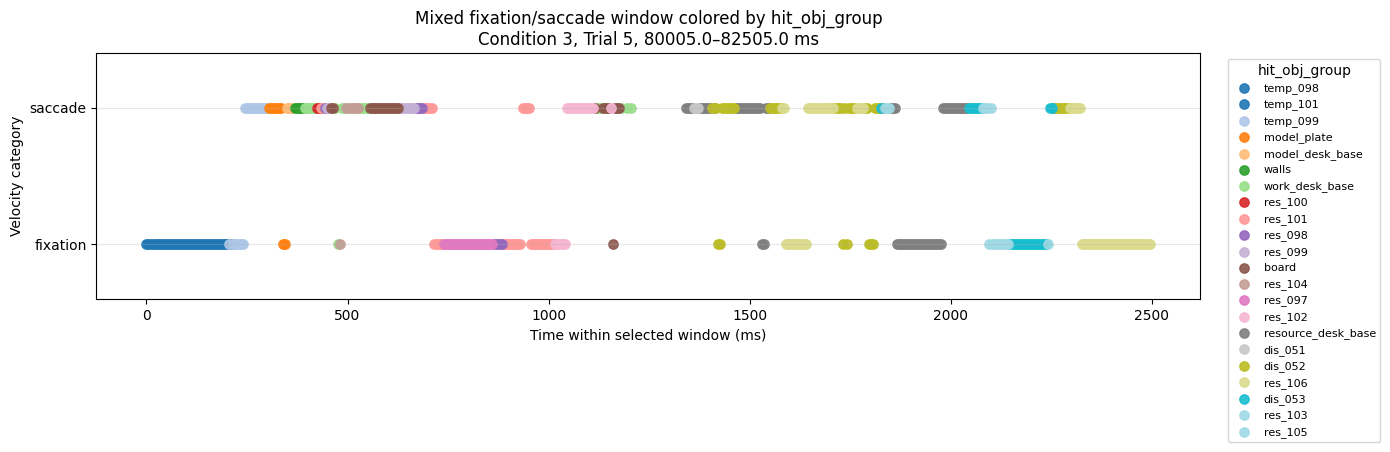

Best candidate window:


,start_ms,end_ms,window_ms,score,n_fixation_samples,n_saccade_samples,n_unique_groups,n_group_changes,n_category_changes,total_samples
0,80005.0016,82505.0016,2500,111,223,248,22,59,30,471


In [121]:
segment, candidates, color_map = plot_mixed_fixation_saccade_window(
    df_clean,
    condition_number=3,
    trial_number=5,
    obj_col="hit_obj_group",
    window_ms=2500,          # 2.5 seconds
    step_ms=500,
    min_fixation_samples=2,
    min_saccade_samples=2
)

In [122]:
fixation_dominance_df = fixation_dominance_for_selected_segment(
    segment,
    category_col="velocity_category",
    obj_col="hit_obj_group"
)

fixation_dominance_df

,local_fixation_run_id,start_ms,end_ms,duration_ms,n_samples,dominant_group,dominance_ratio,n_unique_groups,all_groups_in_fixation
0,1,80005.1527,80245.1844,240.0317,49,temp_098,0.510204,3,"[temp_098, temp_101, temp_099]"
1,3,80345.1972,80350.1967,4.9995,2,model_plate,1.000000,1,[model_plate]
2,5,80480.2165,80485.2192,5.0027,2,work_desk_base,0.500000,2,"[work_desk_base, res_104]"
3,7,80720.2485,80935.2711,215.0226,44,res_097,0.568182,3,"[res_101, res_097, res_098]"
4,9,80960.2750,81045.2846,85.0096,18,res_101,0.666667,2,"[res_101, res_102]"
5,11,81166.3045,81166.3045,0.0000,1,board,1.000000,1,[board]
6,13,81426.3341,81431.3356,5.0015,2,dis_052,1.000000,1,[dis_052]
7,15,81536.3540,81541.3489,4.9949,2,resource_desk_base,1.000000,1,[resource_desk_base]
8,17,81596.3570,81646.3613,50.0043,11,res_106,1.000000,1,[res_106]
9,19,81736.3743,81736.3743,0.0000,1,dis_052,1.000000,1,[dis_052]


Velocity categories in this condition/trial:


,count
velocity_category,
fixation,5949
saccade,2010


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16840\2407380597.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_groups))


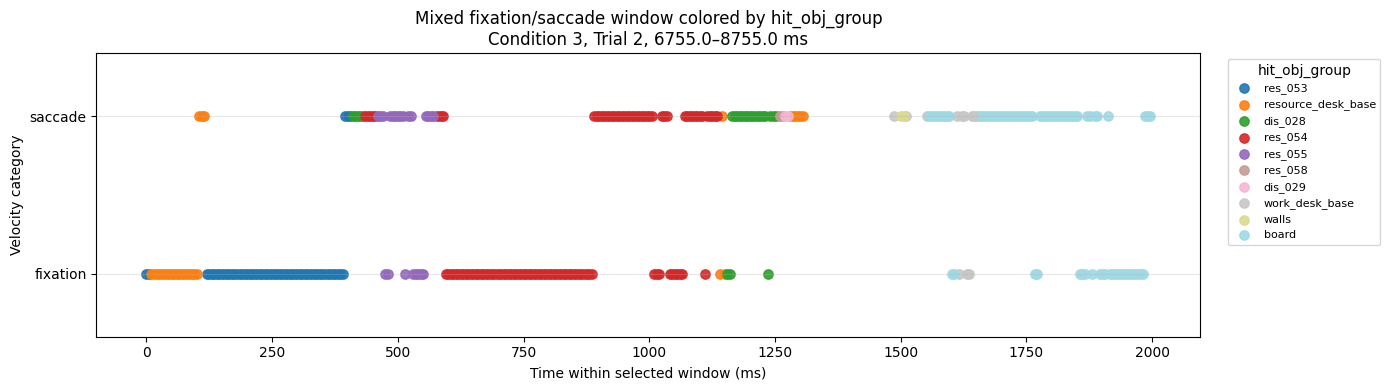

Best candidate window:


,start_ms,end_ms,window_ms,score,n_fixation_samples,n_saccade_samples,n_unique_groups,n_group_changes,n_category_changes,total_samples
0,6755.0008,8755.0008,2000,76,186,170,10,27,39,356


In [123]:
segment, candidates, color_map = plot_mixed_fixation_saccade_window(
    df_clean,
    condition_number=3,
    trial_number=2,
    obj_col="hit_obj_group",
    window_ms=2000,
    step_ms=250,
    min_fixation_samples=2,
    min_saccade_samples=2
)

Velocity categories in this condition/trial:


,count
velocity_category,
fixation,12094
saccade,2979


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16840\2407380597.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_groups))


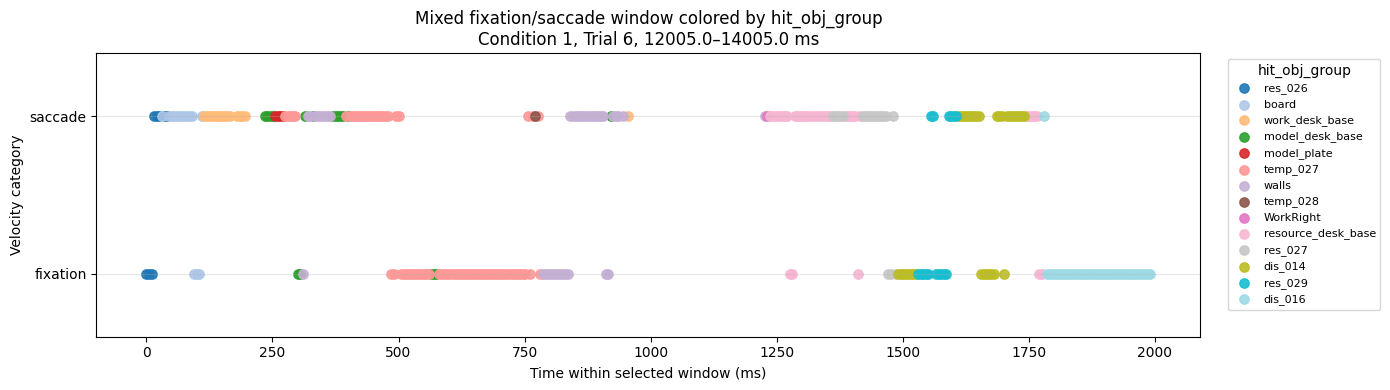

Best candidate window:


,start_ms,end_ms,window_ms,score,n_fixation_samples,n_saccade_samples,n_unique_groups,n_group_changes,n_category_changes,total_samples
0,12005.0015,14005.0015,2000,82,151,184,14,36,32,335


In [124]:
segment, candidates, color_map = plot_mixed_fixation_saccade_window(
    df_clean,
    condition_number=1,
    trial_number=6,
    obj_col="hit_obj_group",
    window_ms=2000,
    step_ms=250,
    min_fixation_samples=2,
    min_saccade_samples=2
)

In [125]:
fixation_dominance_df = fixation_dominance_for_selected_segment(
    segment,
    category_col="velocity_category",
    obj_col="hit_obj_group"
)

fixation_dominance_df

,local_fixation_run_id,start_ms,end_ms,duration_ms,n_samples,dominant_group,dominance_ratio,n_unique_groups,all_groups_in_fixation
0,1,12009.5216,12019.5210,9.9994,3,res_026,1.000000,1,[res_026]
1,3,12104.5374,12114.5374,10.0000,3,board,1.000000,1,[board]
2,5,12309.5630,12319.5633,10.0003,3,model_desk_base,0.666667,2,"[model_desk_base, walls]"
3,7,12494.5865,12499.5860,4.9995,2,temp_027,1.000000,1,[temp_027]
4,9,12514.5874,12760.6220,246.0346,50,temp_027,0.940000,2,"[temp_027, model_desk_base]"
5,11,12770.6217,12770.6217,0.0000,1,temp_027,1.000000,1,[temp_027]
6,13,12790.6269,12845.6344,55.0075,12,walls,0.916667,2,"[temp_027, walls]"
7,15,12920.6391,12925.6396,5.0005,2,walls,1.000000,1,[walls]
8,17,13285.6858,13290.6881,5.0023,2,resource_desk_base,1.000000,1,[resource_desk_base]
9,19,13420.7030,13420.7030,0.0000,1,resource_desk_base,1.000000,1,[resource_desk_base]


Velocity categories in this condition/trial:


,count
velocity_category,
fixation,16365
saccade,4757


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16840\2407380597.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_groups))


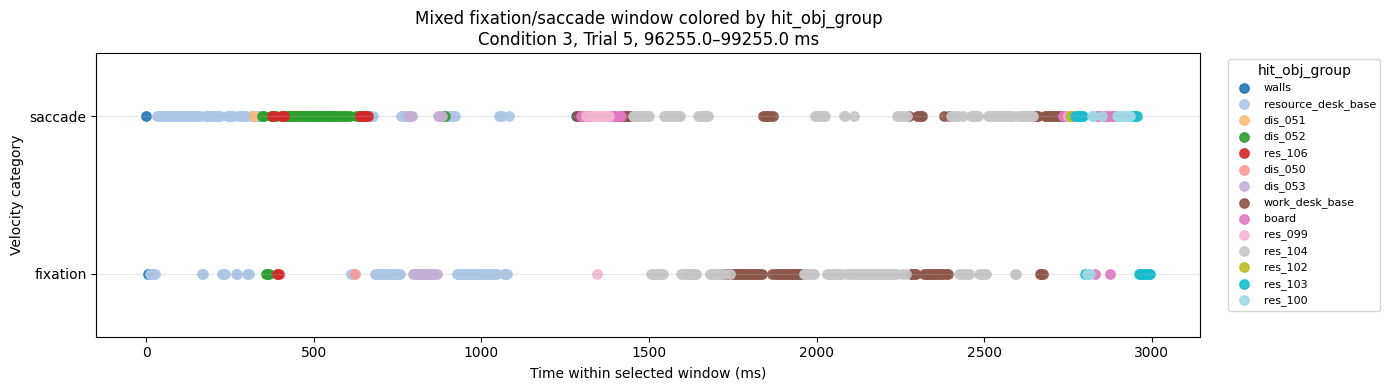

Best candidate window:


,start_ms,end_ms,window_ms,score,n_fixation_samples,n_saccade_samples,n_unique_groups,n_group_changes,n_category_changes,total_samples
0,96255.0016,99255.0016,3000,133,246,315,14,50,69,561


In [127]:
segment, candidates, color_map = plot_mixed_fixation_saccade_window(
    df_clean,
    condition_number=3,
    trial_number=5,
    obj_col="hit_obj_group",
    window_ms=3000,
    step_ms=250,
    min_fixation_samples=2,
    min_saccade_samples=2
)

## After introducing a minimum fixation-duration threshold

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Post-process short fixations
# ------------------------------------------------------------

def remove_short_fixations(
    df,
    category_col="velocity_category",
    time_col="time_ms",
    min_fixation_duration_ms=50,
    new_col="velocity_category_clean"
):
    df = df.copy().sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Make category values safe to compare
    df[category_col] = df[category_col].astype("string")

    df[new_col] = df[category_col]

    df["run_id"] = (
        (df[category_col] != df[category_col].shift()) |
        (df["condition_number"] != df["condition_number"].shift()) |
        (df["trial_number"] != df["trial_number"].shift())
    ).fillna(True).cumsum()

    for run_id, group in df.groupby("run_id", dropna=False):
        label = group[category_col].iloc[0]

        if pd.isna(label):
            continue

        if str(label) != "fixation":
            continue

        duration_ms = group[time_col].max() - group[time_col].min()

        if duration_ms < min_fixation_duration_ms:
            df.loc[group.index, new_col] = "short_fixation"

    return df.drop(columns=["run_id"])


# ------------------------------------------------------------
# 2. Find interesting mixed window
# ------------------------------------------------------------

def find_interesting_mixed_window(
    df,
    condition_number=1,
    trial_number=3,
    time_col="gaze_capture_time",
    category_col="velocity_category_clean",
    obj_col="hit_obj_group",
    window_ms=2500,
    step_ms=500,
    min_fixation_samples=5,
    min_saccade_samples=5,
    min_short_fixation_samples=0,
):
    """
    Find an interesting 2–3 second window containing fixation, short_fixation,
    and/or saccade samples.

    The selected window is scored by:
    - number of hit_obj_group changes
    - number of unique hit_obj_group values
    - number of velocity category changes

    It does NOT require fixation -> saccade -> fixation.
    It only requires enough fixation and saccade samples.
    Short fixations are included as their own category.
    """

    seg = df[
        (df["condition_number"] == condition_number) &
        (df["trial_number"] == trial_number)
    ].copy()

    if seg.empty:
        print("No data found for this condition/trial.")
        return None, None

    seg = seg.sort_values(time_col).reset_index(drop=True)

    # Convert timestamp to ms from trial start
    if time_col == "time_ms":
        seg["time_ms"] = pd.to_numeric(seg[time_col], errors="coerce")
    else:
        t = pd.to_numeric(seg[time_col], errors="coerce")
        seg["time_ms"] = (t - t.min()) / 1e6

    # Keep fixation / short_fixation / saccade
    seg[category_col] = seg[category_col].astype("string").str.strip().str.lower()

    seg = seg[
        seg[category_col].isin(["fixation", "short_fixation", "saccade"])
    ].copy()

    if seg.empty:
        print("No fixation/short_fixation/saccade samples found after filtering.")
        return None, None

    if obj_col not in seg.columns:
        seg[obj_col] = seg["hit_obj_name"].apply(get_object_group)

    seg[obj_col] = seg[obj_col].fillna("No hit").astype(str)

    print("Velocity categories in this condition/trial:")
    display(seg[category_col].value_counts().to_frame("count"))

    candidates = []

    trial_start = seg["time_ms"].min()
    trial_end = seg["time_ms"].max()

    start = trial_start

    while start + window_ms <= trial_end:
        end = start + window_ms

        window = seg[
            (seg["time_ms"] >= start) &
            (seg["time_ms"] <= end)
        ].copy()

        if window.empty:
            start += step_ms
            continue

        n_fix = (window[category_col] == "fixation").sum()
        n_short_fix = (window[category_col] == "short_fixation").sum()
        n_sac = (window[category_col] == "saccade").sum()

        # Require both real fixation and saccade
        if n_fix < min_fixation_samples or n_sac < min_saccade_samples:
            start += step_ms
            continue

        # Optional: require short fixations too
        if n_short_fix < min_short_fixation_samples:
            start += step_ms
            continue

        n_unique_groups = window[obj_col].nunique()

        n_group_changes = (
            window[obj_col] != window[obj_col].shift()
        ).sum() - 1
        n_group_changes = max(n_group_changes, 0)

        n_category_changes = (
            window[category_col] != window[category_col].shift()
        ).sum() - 1
        n_category_changes = max(n_category_changes, 0)

        score = (
            n_group_changes
            + n_unique_groups
            + n_category_changes
            + n_short_fix
        )

        candidates.append({
            "start_ms": start,
            "end_ms": end,
            "window_ms": window_ms,
            "score": score,
            "n_fixation_samples": n_fix,
            "n_short_fixation_samples": n_short_fix,
            "n_saccade_samples": n_sac,
            "n_unique_groups": n_unique_groups,
            "n_group_changes": n_group_changes,
            "n_category_changes": n_category_changes,
            "total_samples": len(window),
        })

        start += step_ms

    if len(candidates) == 0:
        print("No mixed fixation/short_fixation/saccade window found.")
        return None, None

    candidates_df = pd.DataFrame(candidates).sort_values(
        [
            "score",
            "n_category_changes",
            "n_group_changes",
            "n_unique_groups",
            "n_short_fixation_samples"
        ],
        ascending=False
    ).reset_index(drop=True)

    best = candidates_df.iloc[0]

    selected_segment = seg[
        (seg["time_ms"] >= best["start_ms"]) &
        (seg["time_ms"] <= best["end_ms"])
    ].copy()

    return selected_segment, candidates_df


# ------------------------------------------------------------
# 3. Plot selected mixed window
# ------------------------------------------------------------

def plot_mixed_fixation_saccade_window(
    df,
    condition_number=1,
    trial_number=3,
    time_col="gaze_capture_time",
    category_col="velocity_category_clean",
    obj_col="hit_obj_group",
    window_ms=2500,
    step_ms=500,
    min_fixation_samples=5,
    min_saccade_samples=5,
    min_short_fixation_samples=0,
):
    """
    Plot an interesting 2–3 second window containing fixation,
    short_fixation, and saccade samples.

    Points are colored by hit_obj_group.
    Y-axis shows the three velocity categories.
    """

    segment, candidates = find_interesting_mixed_window(
        df=df,
        condition_number=condition_number,
        trial_number=trial_number,
        time_col=time_col,
        category_col=category_col,
        obj_col=obj_col,
        window_ms=window_ms,
        step_ms=step_ms,
        min_fixation_samples=min_fixation_samples,
        min_saccade_samples=min_saccade_samples,
        min_short_fixation_samples=min_short_fixation_samples,
    )

    if segment is None or candidates is None:
        print("Nothing to plot.")
        return None, None, None

    segment = segment.copy()

    # Time starts from 0 inside selected window
    start_ms = segment["time_ms"].min()
    segment["plot_time_ms"] = segment["time_ms"] - start_ms

    # Map three categories to y-axis
    y_map = {
        "fixation": 0,
        "short_fixation": 1,
        "saccade": 2
    }

    segment["y"] = segment[category_col].map(y_map)

    unique_groups = list(segment[obj_col].unique())

    cmap = plt.cm.get_cmap("tab20", len(unique_groups))
    color_map = {group: cmap(i) for i, group in enumerate(unique_groups)}

    plt.figure(figsize=(14, 4.5))

    for group_name in unique_groups:
        sub = segment[segment[obj_col] == group_name]

        plt.scatter(
            sub["plot_time_ms"],
            sub["y"],
            s=45,
            color=color_map[group_name],
            label=group_name,
            alpha=0.9
        )

    plt.yticks(
        [0, 1, 2],
        ["fixation", "short fixation", "saccade"]
    )

    plt.ylim(-0.4, 2.4)

    plt.xlabel("Time within selected window (ms)")
    plt.ylabel("Velocity category")

    best = candidates.iloc[0]

    plt.title(
        f"Mixed fixation / short fixation / saccade window colored by hit_obj_group\n"
        f"Condition {condition_number}, Trial {trial_number}, "
        f"{best['start_ms']:.1f}–{best['end_ms']:.1f} ms"
    )

    plt.grid(axis="y", alpha=0.3)

    plt.legend(
        title="hit_obj_group",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

    print("Best candidate window:")
    display(candidates.head(1))

    return segment, candidates, color_map

In [144]:
df_clean = remove_short_fixations(
    df_clean,
    category_col="velocity_category",
    time_col="time_ms",
    min_fixation_duration_ms=50,
    new_col="velocity_category_clean"
)

Velocity categories in this condition/trial:


,count
velocity_category_clean,
fixation,9456
saccade,3400
short_fixation,490


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16840\1036192839.py:270: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_groups))


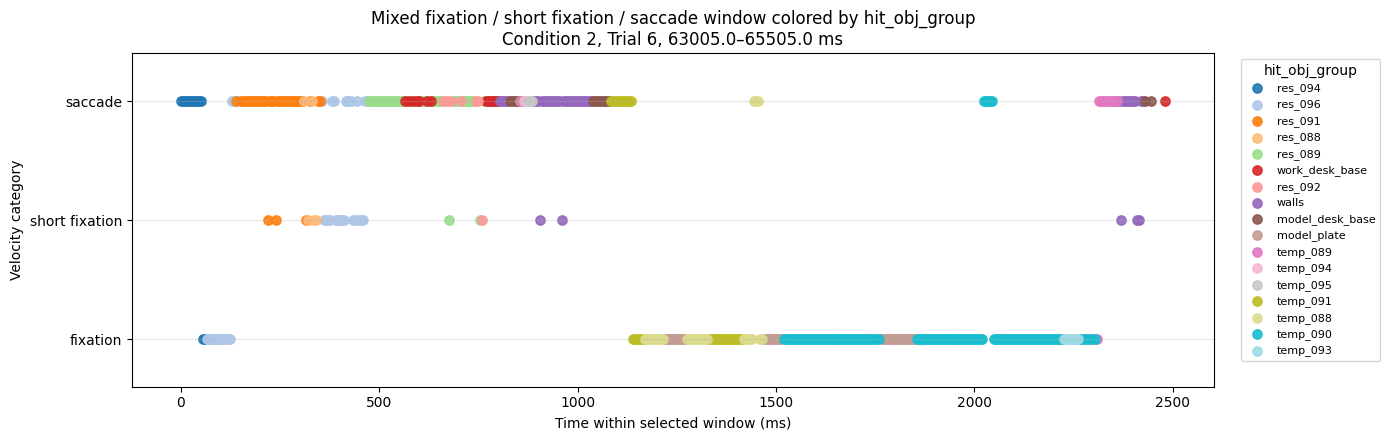

Best candidate window:


,start_ms,end_ms,window_ms,score,n_fixation_samples,n_short_fixation_samples,n_saccade_samples,n_unique_groups,n_group_changes,n_category_changes,total_samples
0,63005.0011,65505.0011,2500,153,242,28,219,17,73,35,489


In [147]:
segment, candidates, color_map = plot_mixed_fixation_saccade_window(
    df_clean,
    condition_number=2,
    trial_number=6,
    time_col="gaze_capture_time",
    category_col="velocity_category_clean",
    obj_col="hit_obj_group",
    window_ms=2500,
    step_ms=500,
    min_fixation_samples=5,
    min_saccade_samples=5,
    min_short_fixation_samples=0
)

Velocity categories in this condition/trial:


,count
velocity_category_clean,
fixation,3105
saccade,1049
short_fixation,119


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16840\1036192839.py:270: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_groups))


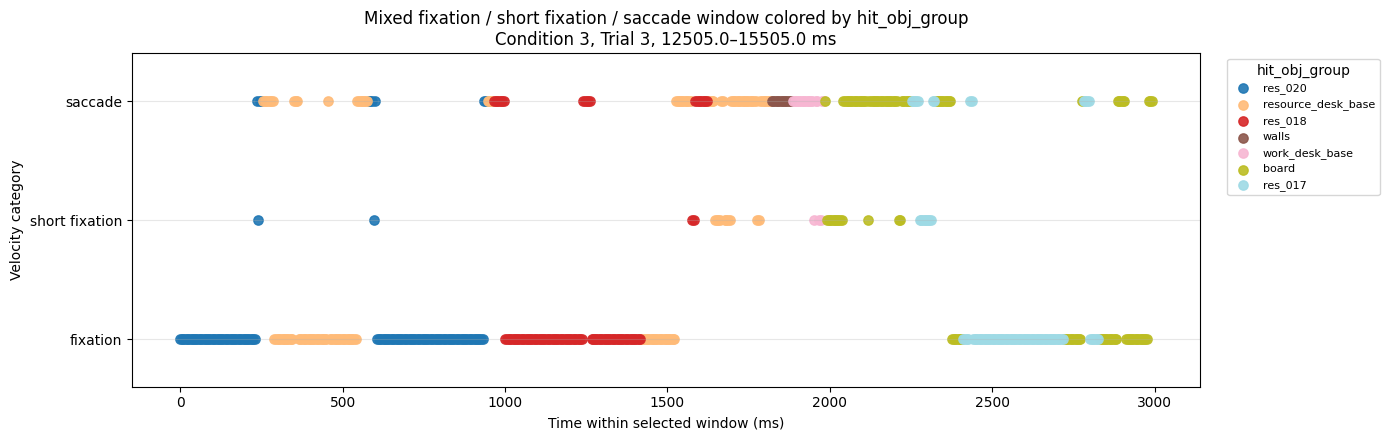

Best candidate window:


,start_ms,end_ms,window_ms,score,n_fixation_samples,n_short_fixation_samples,n_saccade_samples,n_unique_groups,n_group_changes,n_category_changes,total_samples
0,12505.0008,15505.0008,3000,105,369,38,192,7,16,44,599


In [148]:
segment, candidates, color_map = plot_mixed_fixation_saccade_window(
    df_clean,
    condition_number=3,
    trial_number=3,
    time_col="gaze_capture_time",
    category_col="velocity_category_clean",
    obj_col="hit_obj_group",
    window_ms=3000,
    step_ms=500,
    min_fixation_samples=5,
    min_saccade_samples=5,
    min_short_fixation_samples=0
)